In [2]:
# 랜덤 포레스트를 이용한 어떤 영화가 흥행할까?
# 데이터 셋 불러오기, 라이브러리 불러오기

In [3]:
import pandas as pd
df = pd.read_csv('input/movies_train.csv')
df

,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
0,개들의 전쟁,롯데엔터테인먼트,액션,2012-11-22,96,청소년 관람불가,조병옥,NaN,0,91,2,23398
1,내부자들,(주)쇼박스,느와르,2015-11-19,130,청소년 관람불가,우민호,1161602.50,2,387,3,7072501
2,은밀하게 위대하게,(주)쇼박스,액션,2013-06-05,123,15세 관람가,장철수,220775.25,4,343,4,6959083
3,나는 공무원이다,(주)NEW,코미디,2012-07-12,101,전체 관람가,구자홍,23894.00,2,20,6,217866
4,불량남녀,쇼박스(주)미디어플렉스,코미디,2010-11-04,108,15세 관람가,신근호,1.00,1,251,2,483387
...,...,...,...,...,...,...,...,...,...,...,...,...
595,해무,(주)NEW,드라마,2014-08-13,111,청소년 관람불가,심성보,3833.00,1,510,7,1475091
596,파파로티,(주)쇼박스,드라마,2013-03-14,127,15세 관람가,윤종찬,496061.00,1,286,6,1716438
597,살인의 강,(주)마운틴픽쳐스,공포,2010-09-30,99,청소년 관람불가,김대현,NaN,0,123,4,2475
598,악의 연대기,CJ 엔터테인먼트,느와르,2015-05-14,102,15세 관람가,백운학,NaN,0,431,4,2192525


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           600 non-null    str    
 1   distributor     600 non-null    str    
 2   genre           600 non-null    str    
 3   release_time    600 non-null    str    
 4   time            600 non-null    int64  
 5   screening_rat   600 non-null    str    
 6   director        600 non-null    str    
 7   dir_prev_bfnum  270 non-null    float64
 8   dir_prev_num    600 non-null    int64  
 9   num_staff       600 non-null    int64  
 10  num_actor       600 non-null    int64  
 11  box_off_num     600 non-null    int64  
dtypes: float64(1), int64(5), str(6)
memory usage: 105.1 KB


In [5]:
# 결측치 채우기 - fillna()

In [6]:
# 숫자형 컬럼 찾기
numeric_cols = df.select_dtypes(include='number')

In [7]:
# 중간값 구하기
median = numeric_cols.median()
median

time                 100.000
dir_prev_bfnum    478423.625
dir_prev_num           0.000
num_staff             82.500
num_actor              3.000
box_off_num        12591.000
dtype: float64

In [8]:
data = df.fillna(median)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           600 non-null    str    
 1   distributor     600 non-null    str    
 2   genre           600 non-null    str    
 3   release_time    600 non-null    str    
 4   time            600 non-null    int64  
 5   screening_rat   600 non-null    str    
 6   director        600 non-null    str    
 7   dir_prev_bfnum  600 non-null    float64
 8   dir_prev_num    600 non-null    int64  
 9   num_staff       600 non-null    int64  
 10  num_actor       600 non-null    int64  
 11  box_off_num     600 non-null    int64  
dtypes: float64(1), int64(5), str(6)
memory usage: 105.1 KB


In [9]:
# 기술 통계 정보 알아보기

In [10]:
data.describe() # 표준편차가 큰 속성은 모델의 성능 향상에 영향을 미친다.

,time,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
count,600.000000,6.000000e+02,600.000000,600.000000,600.000000,6.000000e+02
mean,100.863333,7.358323e+05,0.876667,151.118333,3.706667,7.081818e+05
std,18.097528,1.233810e+06,1.183409,165.654671,2.446889,1.828006e+06
min,45.000000,1.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
25%,89.000000,4.784236e+05,0.000000,17.000000,2.000000,1.297250e+03
50%,100.000000,4.784236e+05,0.000000,82.500000,3.000000,1.259100e+04
75%,114.000000,4.784236e+05,2.000000,264.000000,4.000000,4.798868e+05
max,180.000000,1.761531e+07,5.000000,869.000000,25.000000,1.426277e+07


In [11]:
# 범주형 데이터 확인하기

In [12]:
# 배급사 속성의 고윳값, 고윳값의 개수
data['distributor'].unique()

<ArrowStringArray>
[       '롯데엔터테인먼트',          '(주)쇼박스',          '(주)NEW',    '쇼박스(주)미디어플렉스',
            '백두대간', '유니버설픽쳐스인터내셔널코리아',          '(주)두타연',       '(주) 케이알씨지',
        '(주)콘텐츠 윙',         '(주)키노아이',
 ...
           '마법사필름',          '스폰지이엔티',        '(주)로드하우스',          '미라클 필름',
     '프리비젼 엔터테인먼트',           '영화사 廊',     '크리에이티브컴즈(주)',          'ysfilm',
             '이달투',            '퍼스트런']
Length: 169, dtype: str

In [13]:
data['distributor'].value_counts()

distributor
CJ 엔터테인먼트      54
롯데엔터테인먼트       52
(주)NEW         30
(주)마운틴픽쳐스      29
(주)쇼박스         26
               ..
영화사 廊           1
크리에이티브컴즈(주)     1
ysfilm          1
이달투             1
퍼스트런            1
Name: count, Length: 169, dtype: int64

In [14]:
# 배급사별 비율

# value_counts(normalize=True) --> 전체 합을 1인 상태에서 모든 값을 비율로 계산 --> 환산
data['distributor'].value_counts(normalize=True)

distributor
CJ 엔터테인먼트      0.090000
롯데엔터테인먼트       0.086667
(주)NEW         0.050000
(주)마운틴픽쳐스      0.048333
(주)쇼박스         0.043333
                 ...   
영화사 廊          0.001667
크리에이티브컴즈(주)    0.001667
ysfilm         0.001667
이달투            0.001667
퍼스트런           0.001667
Name: proportion, Length: 169, dtype: float64

In [15]:
# 장르

data['genre'].unique()

<ArrowStringArray>
[    '액션',    '느와르',    '코미디',  '다큐멘터리',    '뮤지컬',    '드라마', '멜로/로맨스',
     '공포',   '서스펜스',  '애니메이션',   '미스터리',     'SF']
Length: 12, dtype: str

In [16]:
data['genre'].value_counts()

genre
드라마       221
다큐멘터리      93
멜로/로맨스     78
코미디        53
공포         42
액션         28
느와르        27
애니메이션      21
미스터리       17
SF         13
뮤지컬         5
서스펜스        2
Name: count, dtype: int64

In [17]:
# 데이터 시각화하기

In [18]:
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic') #한글 폰트 설정

plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호가 깨지는 현상을 방지

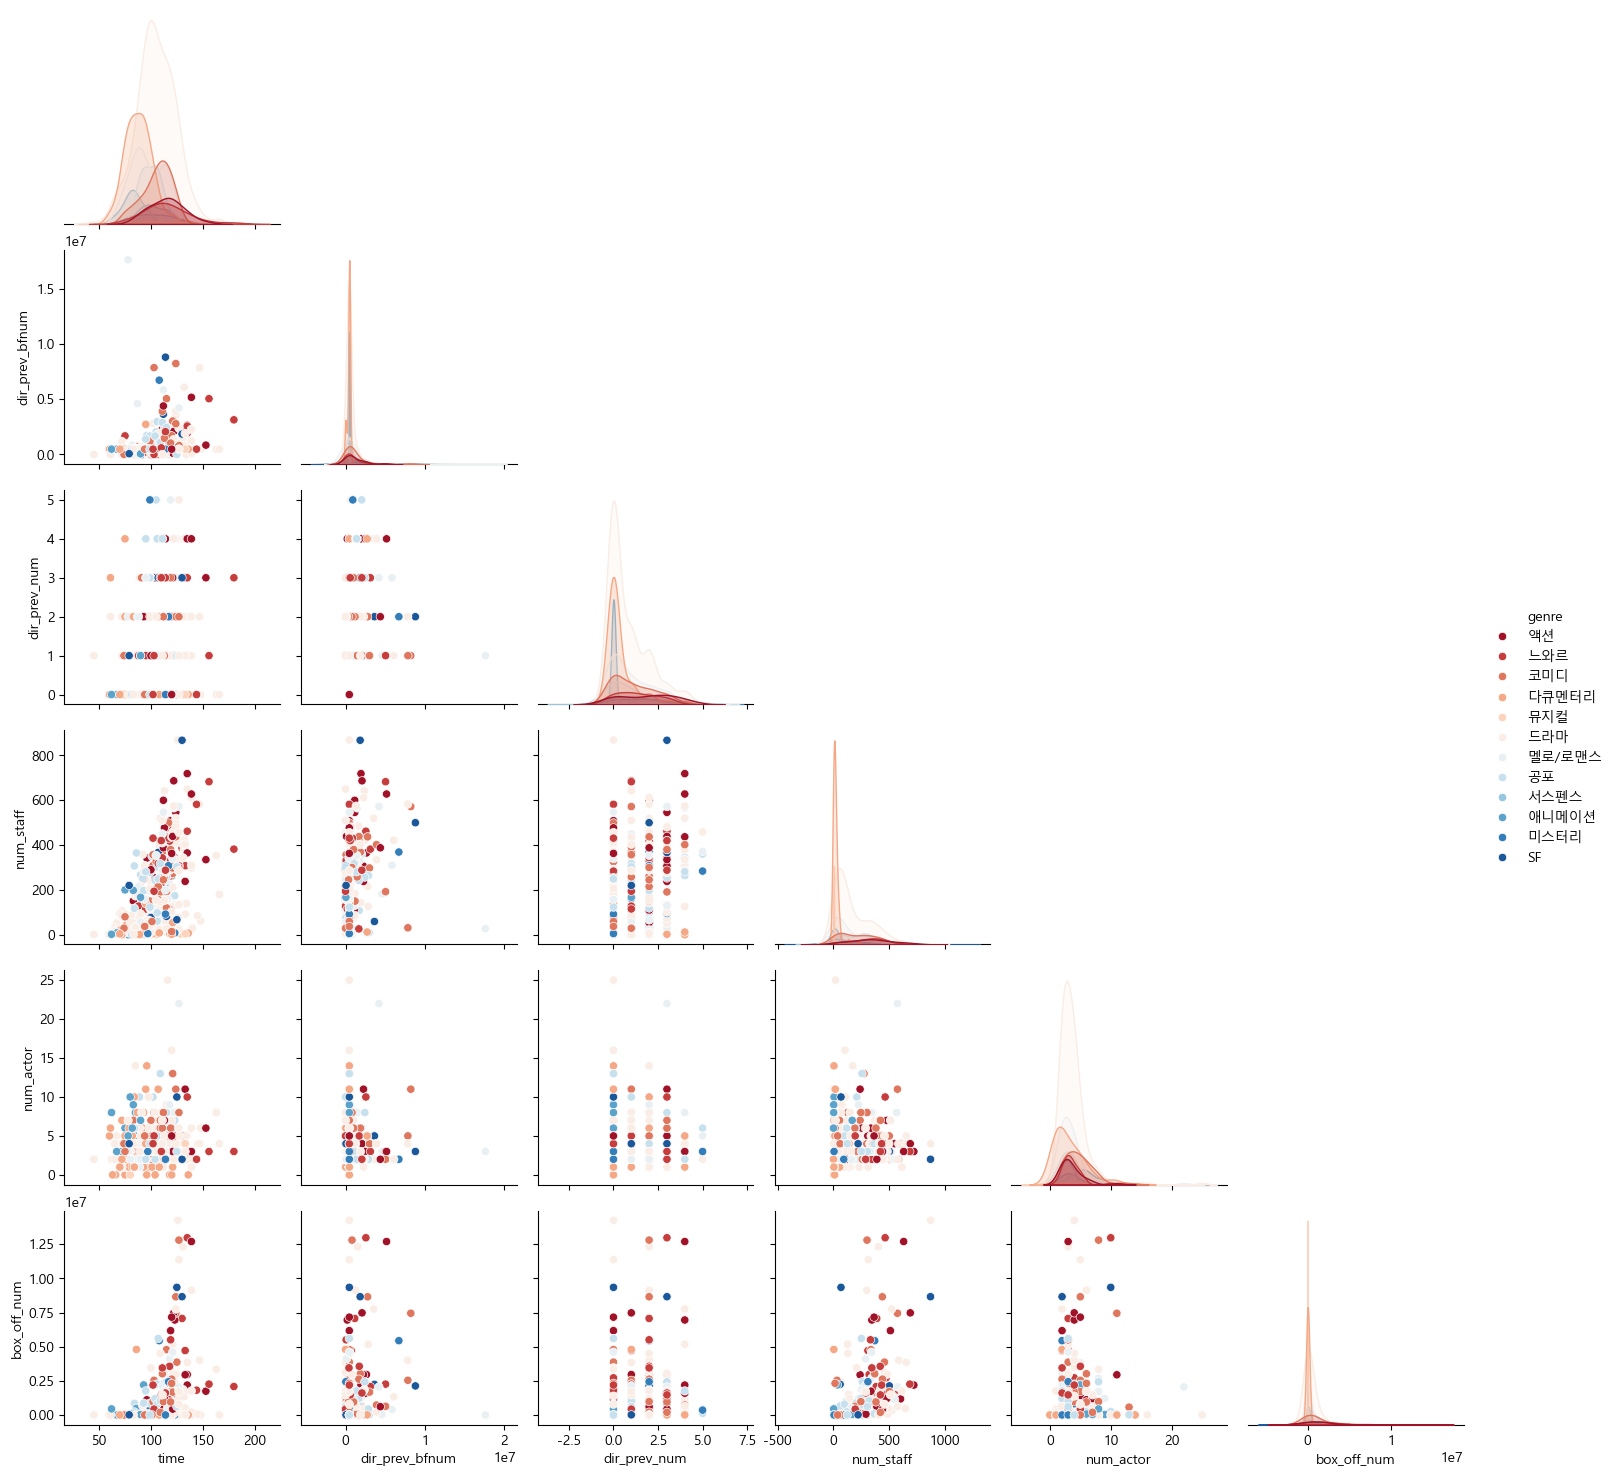

In [19]:
import seaborn as sns
sns.pairplot(data, hue='genre', palette='RdBu', corner=True)
plt.show()

In [20]:
# 상관관계 계산
corr = data.corr(numeric_only=True).round(2) # 소수 둘째자리까지 반올림
corr

,time,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
time,1.00,0.23,0.31,0.62,0.11,0.44
dir_prev_bfnum,0.23,1.00,0.26,0.32,0.05,0.27
dir_prev_num,0.31,0.26,1.00,0.45,0.01,0.26
num_staff,0.62,0.32,0.45,1.00,0.08,0.54
num_actor,0.11,0.05,0.01,0.08,1.00,0.11
box_off_num,0.44,0.27,0.26,0.54,0.11,1.00


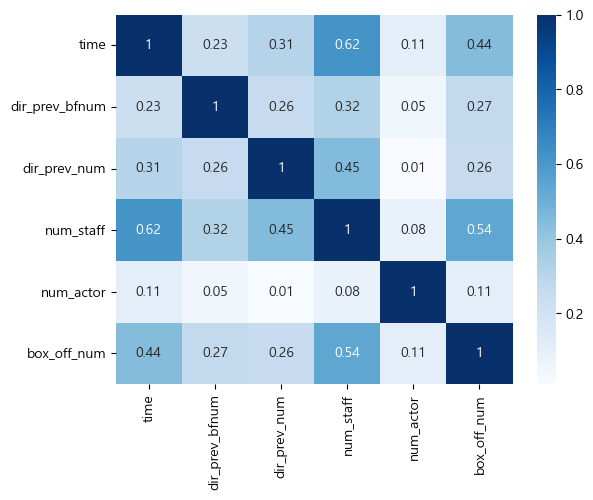

In [21]:
# 히트맵 그래프 그리기
sns.heatmap(corr, annot=True, cmap='Blues')
plt.show()

In [22]:
# '흥행' 속성 추가

# - 관객 수를 기준으로 흥행/비흥행 구분
# - 100만명이 넘으면 흥행, 아니면 비흥행

In [23]:
import numpy as np

# '흥행' 속성 = np.where(조건식, 참, 거짓)
data['hit'] = np.where(data['box_off_num'] >= 1000000, 1, 0)

In [24]:
data.tail()

,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num,hit
595,해무,(주)NEW,드라마,2014-08-13,111,청소년 관람불가,심성보,3833.000,1,510,7,1475091,1
596,파파로티,(주)쇼박스,드라마,2013-03-14,127,15세 관람가,윤종찬,496061.000,1,286,6,1716438,1
597,살인의 강,(주)마운틴픽쳐스,공포,2010-09-30,99,청소년 관람불가,김대현,478423.625,0,123,4,2475,0
598,악의 연대기,CJ 엔터테인먼트,느와르,2015-05-14,102,15세 관람가,백운학,478423.625,0,431,4,2192525,1
599,베를린,CJ 엔터테인먼트,액션,2013-01-30,120,15세 관람가,류승완,478423.625,0,363,5,7166532,1


In [25]:
# 흥행 영화가 몇 개인가? --> hit 속성이 1인 데이터

In [26]:
data['hit'].sum()

np.int64(109)

In [27]:
# 독립변수(입력, 피쳐)와 종속변수(정답, 타겟) 정하기

# - 독립변수 : 배급사, 장르, 상영등급, 감독의 전작 평균 관객 수, 감독 전작 영화 수, 스탭 수, 주연 배우 수
# - 종속변수 : 흥행(hit)

In [28]:
data.head(1)

,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num,hit
0,개들의 전쟁,롯데엔터테인먼트,액션,2012-11-22,96,청소년 관람불가,조병옥,478423.625,0,91,2,23398,0


In [29]:
X = data.iloc[:, [1, 2, 5, 7, 8, 9, 10]]
X

,distributor,genre,screening_rat,dir_prev_bfnum,dir_prev_num,num_staff,num_actor
0,롯데엔터테인먼트,액션,청소년 관람불가,478423.625,0,91,2
1,(주)쇼박스,느와르,청소년 관람불가,1161602.500,2,387,3
2,(주)쇼박스,액션,15세 관람가,220775.250,4,343,4
3,(주)NEW,코미디,전체 관람가,23894.000,2,20,6
4,쇼박스(주)미디어플렉스,코미디,15세 관람가,1.000,1,251,2
...,...,...,...,...,...,...,...
595,(주)NEW,드라마,청소년 관람불가,3833.000,1,510,7
596,(주)쇼박스,드라마,15세 관람가,496061.000,1,286,6
597,(주)마운틴픽쳐스,공포,청소년 관람불가,478423.625,0,123,4
598,CJ 엔터테인먼트,느와르,15세 관람가,478423.625,0,431,4


In [30]:
y = data['hit']
y

0      0
1      1
2      1
3      0
4      0
      ..
595    1
596    1
597    0
598    1
599    1
Name: hit, Length: 600, dtype: int64

In [31]:
# 원 - 핫 인코딩

# pd.get_dummies(데이터프레임, columns=['인코딩할 속성명'])

In [32]:
X = pd.get_dummies(X, columns=['distributor', 'genre', 'screening_rat'])

In [33]:
X.head()

,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,distributor_(주) 브릿지웍스,distributor_(주) 액티버스엔터테인먼트,distributor_(주) 영화사조제,distributor_(주) 영화제작전원사,distributor_(주) 케이알씨지,distributor_(주)JK필름,...,genre_뮤지컬,genre_미스터리,genre_서스펜스,genre_애니메이션,genre_액션,genre_코미디,screening_rat_12세 관람가,screening_rat_15세 관람가,screening_rat_전체 관람가,screening_rat_청소년 관람불가
0,478423.625,0,91,2,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
1,1161602.500,2,387,3,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,220775.250,4,343,4,False,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,False
3,23894.000,2,20,6,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
4,1.000,1,251,2,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False


In [34]:
# 훈련 데이터와 테스트(검증) 데이터 나누기

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_trian, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_trian.shape, y_test.shape

((480, 189), (120, 189), (480,), (120,))

In [36]:
# 랜던 포레스트 모델 학습시키기

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_trian)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [38]:
# 훈련 데이터에 대한 랜덤 포레스트 모델의 정확도 출력

In [39]:
rf.score(X_train, y_trian) # 과적합

1.0

In [40]:
# 테스트용 데이터를 이용해서 모델 테스트 및 평가

In [41]:
y_pred = rf.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [42]:
result = pd.DataFrame({'Actual Value':y_test,
                       'model prediction':y_pred})

In [43]:
result.head()

,Actual Value,model prediction
110,1,0
419,0,0
565,0,0
77,0,0
181,1,0


In [44]:
# 평가하기

In [45]:
rf.score(X_test, y_test)

0.8083333333333333

In [46]:
# 평가 분류표 출력

In [48]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.96      0.88        92
           1       0.69      0.32      0.44        28

    accuracy                           0.81       120
   macro avg       0.76      0.64      0.66       120
weighted avg       0.79      0.81      0.78       120



In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred) # 정확도 

0.8083333333333333

In [54]:
from sklearn.metrics import f1_score

f1_score(y_test, y_pred)

0.43902439024390244

In [51]:
# 혼동행렬 출력

# - 실젯값과 모델이 예측한 값을 비교
# - TP, TN, FP, FN

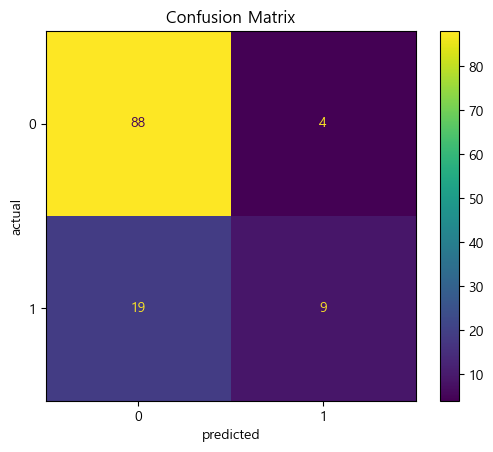

In [56]:
from sklearn import metrics

confusion_matrix = metrics.confusion_matrix(y_true=y_test, y_pred=y_pred)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix)
cm_display.plot()
plt.title('Confusion Matrix')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.show()


In [57]:
# max_depth = 수치를 준다

In [59]:
from sklearn.ensemble import RandomForestClassifier

rf2 = RandomForestClassifier(max_depth=3, random_state=42)
rf2.fit(X_train, y_trian)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [60]:
rf2.score(X_train, y_trian)

0.8416666666666667

In [61]:
rf2.score(X_test, y_test)

0.7666666666666667

In [62]:
y_pred2 = rf2.predict(X_test)
y_pred2

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [63]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred2)

0.7666666666666667

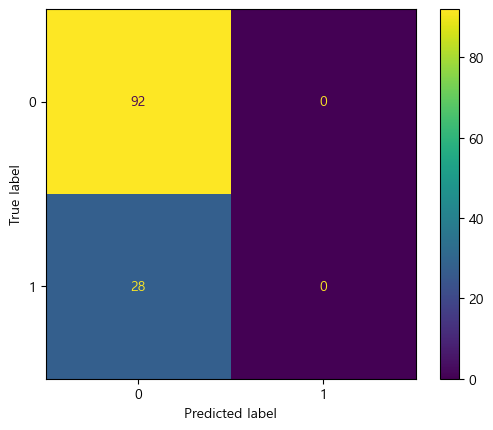

In [64]:
confusion_matrix2 = metrics.confusion_matrix(y_test, y_pred2)
cm_display2 = metrics.ConfusionMatrixDisplay(confusion_matrix2)
cm_display2.plot()
plt.show()

In [65]:
from sklearn.ensemble import RandomForestClassifier

rf3 = RandomForestClassifier(max_depth=5, random_state=42)
rf3.fit(X_train, y_trian)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [66]:
rf3.score(X_train, y_trian)

0.8791666666666667

In [67]:
rf2.score(X_test, y_test)

0.7666666666666667

In [68]:
y_pred3 = rf3.predict(X_test)
y_pred3

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [69]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred3)

0.7916666666666666

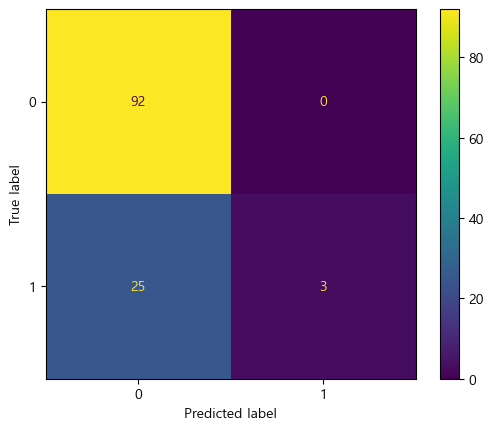

In [71]:
confusion_matrix3 = metrics.confusion_matrix(y_test, y_pred3)
cm_display3 = metrics.ConfusionMatrixDisplay(confusion_matrix3)
cm_display3.plot()
plt.show()